# Credit Risk Modeling and Validation: Logistic Regression vs. XGBoost

The analysis focuses on the out-of-sample reliability of estimated probabilities of default (PDs) and their use in lending decisions. A Logistic Regression benchmark is compared with XGBoost, followed by model validation and a lending-policy exercise.


## 1. Objective and data

The sample is a reproducible random draw of 10,000 LendingClub loans issued in 2014, including 36- and 60-month loans. Predictors contain only information available by the time the loan is issued, while repayment and default outcomes, summarized by the loan status variable, are observed ex post.

The predictor set is based on 20 variables, including loan amount, term, annual interest rate, annual income, debt-to-income ratio (DTI) and further information on previous credit activity. The list is intentionally non-exhaustive: it provides a compact set of economically relevant variables covering loan terms, repayment capacity, credit history, revolving-credit use and basic loan/borrower characteristics rather than using every field available in the raw data.

**Data source:** Kaggle, *Lending Club 2007–2020Q3*:  
https://www.kaggle.com/datasets/ethon0426/lending-club-20072020q1

Place `Loan_status_2007-2020Q3.gzip` in the local `data/` folder before running the notebook. Variable definitions follow the LendingClub data dictionary `LCDataDictionary.xlsx`, included in the same dataset.


In [1]:
# Load the data, select a compact non-exhaustive set of relevant fields, and draw a reproducible 10,000-loan sample from the 2014 vintage.

import pandas as pd

import numpy as np

import xgboost as xgb

loan_path = "data/Loan_status_2007-2020Q3.gzip"

selected_columns = [

    'loan_status',

    'issue_d',

    'loan_amnt',

    'term',

    'int_rate',

    'installment',

    'annual_inc',

    'emp_length',

    'home_ownership',

    'verification_status',

    'purpose',

    'dti',

    'fico_range_low',

    'fico_range_high',

    'delinq_2yrs',

    'inq_last_6mths',

    'open_acc',

    'pub_rec',

    'revol_bal',

    'revol_util',

    'total_acc',

    'earliest_cr_line'

]

df_main = pd.read_csv(

    loan_path,

    usecols = selected_columns

)

df_2014_large = df_main[

    df_main['issue_d'].str.endswith('2014', na=False)

].copy()

df_2014 = df_2014_large.sample(n=10000, random_state=42).copy()


### 1.1 Target definition

The target is loan status: `Fully Paid = 0`, while `Charged Off` and `Default = 1`. Unresolved outcomes are excluded. Using a random sample of loans issued in 2014 leaves enough time for both loan terms to reach a resolved outcome before the dataset ends in 2020 Q3.

Because final loan outcomes are used for both 36- and 60-month loans, this is not the one-year PD used in the Basel IRB framework. A one-year version could use the same modeling setup but define the target as 1 only if default occurs within 12 months after the loan is issued.


In [2]:
# Define the resolved binary target: 0 = non-default, 1 = default.

df_2014['loan_status_old'] = df_2014['loan_status']

print(df_2014[['loan_status','loan_status_old']].head())

print(df_2014['loan_status'].value_counts(dropna=False))  # Show all raw status categories, including missing values.

df_2014.loc[df_2014['loan_status_old'] == 'Charged Off','loan_status'] = 1

df_2014.loc[df_2014['loan_status_old'] == 'Default','loan_status'] = 1

df_2014.loc[df_2014['loan_status_old'] == 'Fully Paid','loan_status'] = 0

df_2014.loc[df_2014['loan_status_old'] == 'Current','loan_status'] = pd.NA

df_2014.loc[df_2014['loan_status_old'] == 'Late (31-120 days)','loan_status'] = pd.NA

df_2014.loc[df_2014['loan_status_old'] == 'In Grace Period','loan_status'] = pd.NA

print('Check whether there are remaining string values (not 0,1 or NA) in loan_status that need to be transformed.')

print(df_2014['loan_status'].value_counts(dropna=False))

df_2014['loan_status'] = df_2014['loan_status'].astype('Int64')

print(df_2014['loan_status'].value_counts(dropna=False))

print(df_2014['loan_status'].dtype)


        loan_status loan_status_old
1506318  Fully Paid      Fully Paid
1592229  Fully Paid      Fully Paid
1506931  Fully Paid      Fully Paid
1605282  Fully Paid      Fully Paid
1511304  Fully Paid      Fully Paid
loan_status
Fully Paid     8215
Charged Off    1784
Current           1
Name: count, dtype: int64
Check whether there are remaining string values (not 0,1 or NA) in loan_status that need to be transformed.
loan_status
0       8215
1       1784
<NA>       1
Name: count, dtype: int64
loan_status
0       8215
1       1784
<NA>       1
Name: count, dtype: Int64
Int64


### 1.2 Feature engineering and preprocessing


In [3]:
# Convert loan term to numeric months.

df_2014['term'] = (df_2014['term'].str.strip().map({'36 months': 36, '60 months': 60}))

print(df_2014['term'].value_counts(dropna=False))  # dropna=False also counts missing values.


term
36    6921
60    3079
Name: count, dtype: int64


In [4]:
# Convert interest rate to numeric percentage points.

df_2014['int_rate'] = (

    df_2014['int_rate']

    .str.strip()

    .str.rstrip('%')

    .astype(float)

)

print(df_2014['int_rate'].head())

print(df_2014['int_rate'].dtype)


1506318     6.03
1592229    13.35
1506931    17.86
1605282    14.49
1511304     8.19
Name: int_rate, dtype: float64
float64


In [5]:
# Map employment length to years (10 = 10+ years).

df_2014['emp_length'] = (

    df_2014['emp_length']

    .str.strip()

    .map({

    '< 1 year':  0,

    '1 year':    1,

    '2 years':   2,

    '3 years':   3,

    '4 years':   4,

    '5 years':   5,

    '6 years':   6,

    '7 years':   7,

    '8 years':   8,

    '9 years':   9,

    '10+ years': 10})

)


In [6]:
# Use the midpoint of the reported FICO range.

df_2014['fico_midpoint'] = (df_2014['fico_range_high'] + df_2014['fico_range_low']) / 2

print(df_2014['fico_midpoint'].head())


1506318    757.0
1592229    712.0
1506931    697.0
1605282    702.0
1511304    712.0
Name: fico_midpoint, dtype: float64


In [7]:
# Convert revolving utilization to numeric percentage points.

df_2014['revol_util'] = (df_2014['revol_util']

.str.strip()

.str.rstrip('%')

.astype(float)

)

print(df_2014['revol_util'].head())


1506318    36.3
1592229    60.6
1506931    46.9
1605282    96.7
1511304    50.1
Name: revol_util, dtype: float64


In [8]:
# Compute loan-to-income and credit-history-length predictors.

print((df_2014['annual_inc'] <= 0).sum())

df_2014['loan_income_ratio'] = 100*df_2014['loan_amnt'] / df_2014['annual_inc']

df_2014.loc[df_2014['annual_inc'] <= 0, 'loan_income_ratio'] = pd.NA

df_2014['issue_d'] = pd.to_datetime(df_2014['issue_d'], format='mixed')

df_2014['earliest_cr_line'] = pd.to_datetime(df_2014['earliest_cr_line'], format='mixed')

df_2014['credit_history_length'] = (

    (df_2014['issue_d'] - df_2014['earliest_cr_line']).dt.days / 365.25  # Approx. years from first recorded credit line to loan issue.

)


0


In [9]:
# Keep only resolved loan outcomes; this overwrites df_2014 with the filtered rows, while .copy() creates an independent DataFrame.

df_2014 = df_2014[df_2014['loan_status'].notna()].copy()


In [10]:
# Define target, numerical predictors, categorical predictors and documentation fields.

target_cols = [

    'loan_status'

]

predictor_cols = [

    'loan_amnt',

    'term',

    'int_rate',

    'installment',

    'annual_inc',

    'emp_length',

    'dti',

    'fico_midpoint',

    'delinq_2yrs',

    'inq_last_6mths',

    'open_acc',

    'pub_rec',

    'revol_bal',

    'revol_util',

    'total_acc',

    'loan_income_ratio',

    'credit_history_length'

]

categorical_predictor_cols = [

    'home_ownership',

    'verification_status',

    'purpose'

]

nuisance_cols = [

    'issue_d',

    'earliest_cr_line',

    'fico_range_low',

    'fico_range_high',

    'loan_status_old'

]

df_2014 = df_2014[

    target_cols + predictor_cols + categorical_predictor_cols  + nuisance_cols

]


#### Predictor overview

The definitions below follow the LendingClub data dictionary where applicable. Variables explicitly constructed in this notebook are marked as such.

| Variable | Definition |
|---|---|
| `loan_amnt` | Listed loan amount applied for by the borrower. If LendingClub reduced the requested amount before origination, the recorded value reflects that reduction. |
| `term` | Number of scheduled loan payments, expressed in months. The loans in this sample have terms of either 36 or 60 months. |
| `int_rate` | Annual interest rate assigned to the loan, expressed in percentage points. |
| `installment` | Monthly payment owed by the borrower if the loan originates. It is mechanically related to loan amount, interest rate and term. |
| `annual_inc` | Self-reported annual income provided by the borrower during registration. |
| `emp_length` | Employment length in years. In the processed variable, 0 represents less than one year and 10 represents ten or more years. |
| `dti` | Debt-to-income ratio: the borrower's monthly debt payments relative to self-reported monthly income, excluding mortgage payments and the requested LendingClub loan. Higher values indicate a larger existing debt burden relative to income. |
| `fico_midpoint` | **Constructed variable.** Midpoint of the lower and upper FICO-score range reported at loan origination. FICO is a widely used U.S. consumer credit score; higher values generally indicate stronger creditworthiness. |
| `delinq_2yrs` | Number of 30+ day past-due delinquency incidences in the borrower's credit file during the previous two years. |
| `inq_last_6mths` | Number of credit inquiries during the previous six months, excluding auto and mortgage inquiries. |
| `open_acc` | Number of open credit lines in the borrower's credit file. |
| `pub_rec` | Number of derogatory public records in the borrower's credit file. |
| `revol_bal` | Total outstanding balance on revolving credit accounts, such as credit cards. |
| `revol_util` | Revolving-credit utilization rate: revolving credit used relative to the total available revolving credit. |
| `total_acc` | Total number of credit lines recorded in the borrower's credit file. |
| `loan_income_ratio` | **Constructed variable.** Loan amount divided by annual income and multiplied by 100. It measures the requested loan amount relative to the borrower's annual income. |
| `credit_history_length` | **Constructed variable.** Approximate number of years between the earliest reported credit line and the loan issue date. |
| `home_ownership` | Home-ownership status reported by the borrower or obtained from the credit report, such as rent, own or mortgage. |
| `verification_status` | Indicates whether LendingClub verified the borrower's income, did not verify it, or verified the income source. |
| `purpose` | Borrower-provided category describing the stated purpose of the loan request. |


#### Categorical variables

`home_ownership`, `verification_status` and `purpose` are one-hot encoded and combined with the numerical predictors.


In [11]:
# One-hot encode categorical origination variables.

print(df_2014.dtypes)

object_features = df_2014[categorical_predictor_cols].copy()

dummy_variables = pd.get_dummies(object_features)

df_model = pd.concat([df_2014[target_cols + predictor_cols], dummy_variables] ,axis=1)


loan_status                       Int64
loan_amnt                       float64
term                              int64
int_rate                        float64
installment                     float64
annual_inc                      float64
emp_length                      float64
dti                             float64
fico_midpoint                   float64
delinq_2yrs                     float64
inq_last_6mths                  float64
open_acc                        float64
pub_rec                         float64
revol_bal                       float64
revol_util                      float64
total_acc                       float64
loan_income_ratio               float64
credit_history_length           float64
home_ownership                   object
verification_status              object
purpose                          object
issue_d                  datetime64[ns]
earliest_cr_line         datetime64[ns]
fico_range_low                  float64
fico_range_high                 float64


### 1.3 Missing values and train/test split

The data are split 60/40 into training and test samples, stratified by the target so that the default share is preserved in both. Missing `emp_length` and `revol_util` values are imputed using the training-sample median, with the same values applied to the test sample. Numerical scaling for the Logit also uses training-sample moments.


In [12]:
# Stratified train/test split; impute test data using training-sample medians only.

from sklearn.model_selection import train_test_split

y = df_model['loan_status']

X = df_model.drop('loan_status', axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = .4, random_state = 42, stratify = y)

# normalize=True returns proportions rather than counts, making the class/default shares easy to compare.
print(y_train.value_counts(normalize=True))

print(y_test.value_counts(normalize=True))

for col in ['emp_length', 'revol_util']:

    train_median = X_train[col].median()

    X_train[col] = X_train[col].fillna(train_median)

    X_test[col] = X_test[col].fillna(train_median)

print(X_train[['emp_length', 'revol_util']].isna().sum())

print(X_test[['emp_length', 'revol_util']].isna().sum())


loan_status
0    0.821637
1    0.178363
Name: proportion, dtype: Float64
loan_status
0    0.8215
1    0.1785
Name: proportion, dtype: Float64
emp_length    0
revol_util    0
dtype: int64
emp_length    0
revol_util    0
dtype: int64


### 1.4 Exploratory data analysis

EDA is restricted to the training sample. The summary tables and histograms are used mainly to check that the predictors show useful variation and to identify extreme or implausible values that could indicate data problems. Several financial variables are right-skewed, which is plausible for this type of data, so observations are not removed simply because a distribution is skewed.

Revolving utilization above 100% is inspected separately. Such values can occur when the reported revolving balance exceeds the reported credit limit, so they are not automatically data errors.


loan_status
0    0.821637
1    0.178363
Name: proportion, dtype: Float64


                               min           50%          mean            max
loan_amnt              1000.000000  12800.000000  14745.999333   35000.000000
term                     36.000000     36.000000     43.165194      60.000000
int_rate                  6.000000     13.650000     13.759653      26.060000
installment              33.060000    382.230000    440.374896    1344.830000
annual_inc             8208.000000  65000.000000  73985.548536  700000.000000
emp_length                0.000000      7.000000      6.214369      10.000000
dti                       0.000000     17.310000     17.878970      39.700000
fico_midpoint           662.000000    687.000000    694.241207     842.000000
delinq_2yrs               0.000000      0.000000      0.345891      14.000000
inq_last_6mths            0.000000      0.000000      0.762794       6.000000
open_acc                  2.000000     11.000000     11.681447      40.000000
pub_rec                   0.000000      0.000000      0.232039  

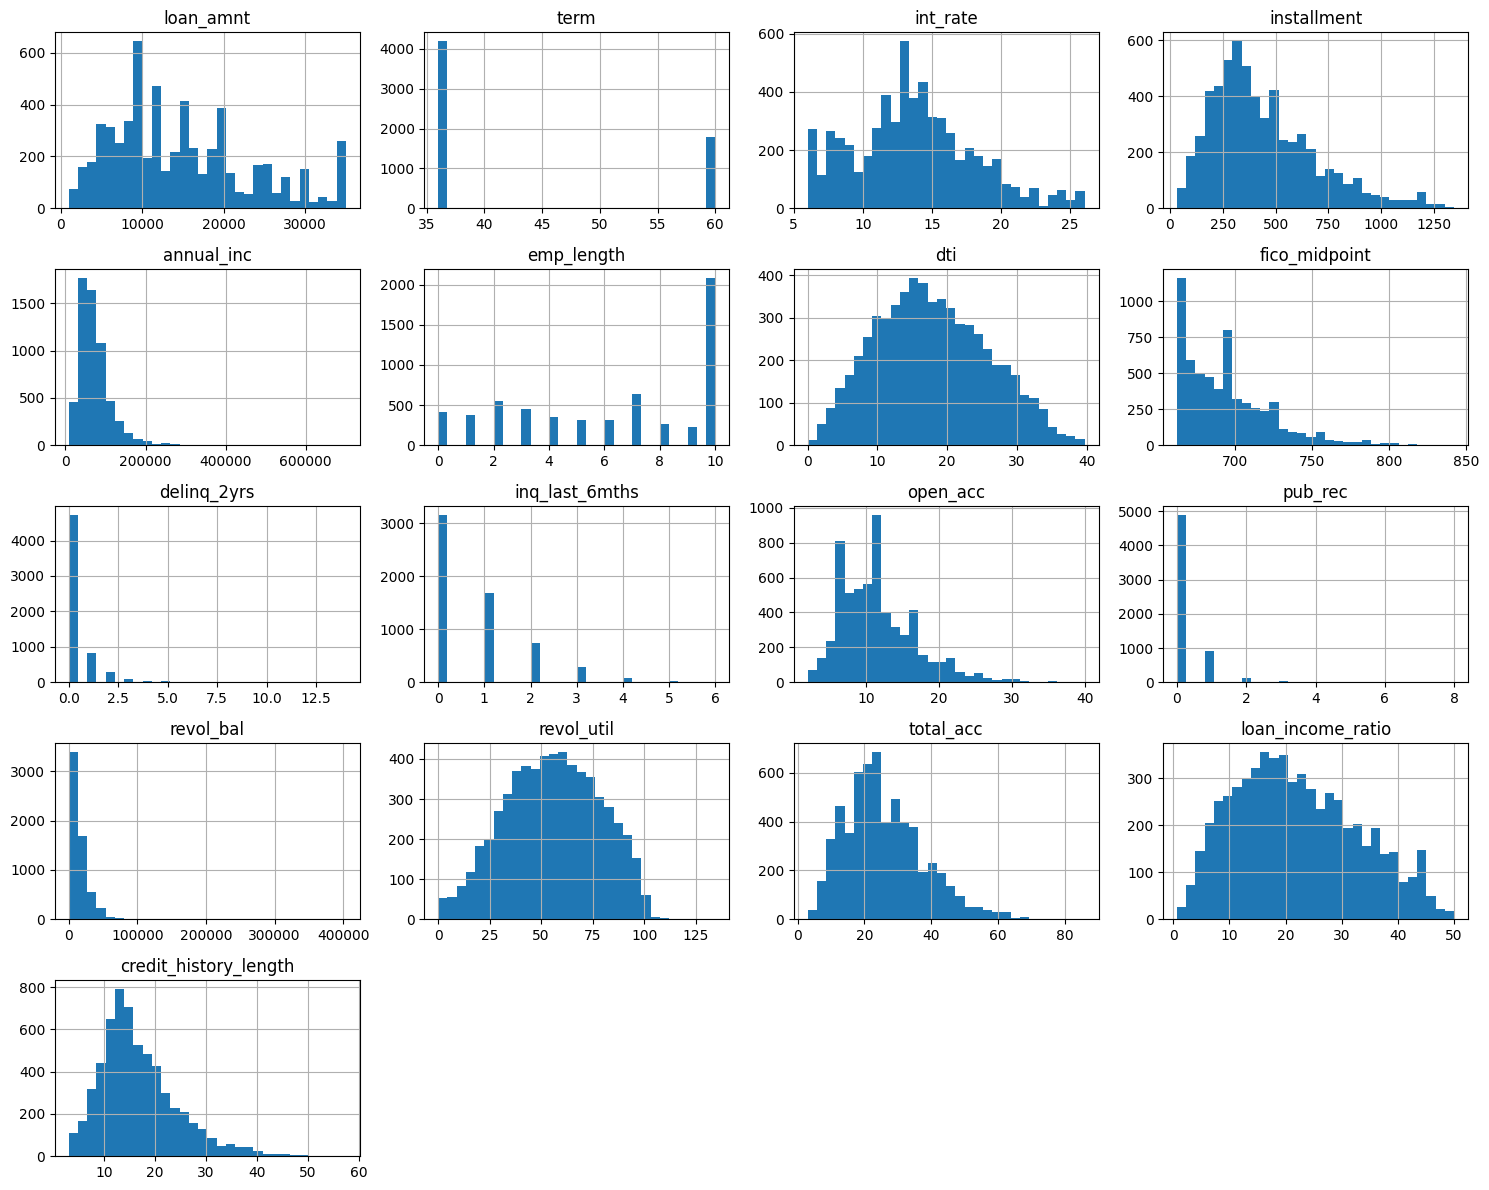

In [13]:
# Compact EDA on the training sample.

print(y_train.value_counts(normalize=True))

print(X_train[predictor_cols].describe().T[['min', '50%', 'mean', 'max']])

import matplotlib.pyplot as plt

X_train[predictor_cols].hist(

    bins=30,

    figsize=(15, 12)

)

plt.tight_layout()

plt.show()


In [14]:
# Inspect revolving utilization above 100%; balances can exceed reported credit limits, so values above 100% are not automatically errors.

print((X_train['revol_util'] > 100).sum())

print(

    X_train.loc[X_train['revol_util'] > 100, 'revol_util']

    .sort_values(ascending=False)

    .head(10)

)


38
1625224    134.5
1536848    125.3
1532712    113.4
1605853    109.3
1572877    108.3
1615284    106.6
1576097    106.3
1668074    104.5
1691357    103.5
1492221    103.3
Name: revol_util, dtype: float64


## 2. Models

### Logistic Regression

An L2-regularized Logit is used as the benchmark. The underlying probability-forecast loss is **log-loss**,

$$
-\frac{1}{N}\sum_{i=1}^{N}\left[y_i\log(\widehat{PD}_i)
+(1-y_i)\log(1-\widehat{PD}_i)\right].
$$

Log-loss is the negative log-likelihood for the binary default outcome: it rewards probabilities that are close to the realized outcome and penalizes confident wrong predictions particularly strongly.

L2 adds a penalty for large coefficients,

$$
\text{log-loss} + \lambda\sum_j \beta_j^2,
$$

so coefficients are pulled toward zero, which can make the model more stable and reduce overfitting. L2 generally does not set coefficients exactly to zero. In scikit-learn, the regularization strength is inversely related to `C`: smaller `C` means stronger regularization.

Numerical predictors are standardized using training-sample moments; dummy variables remain 0/1.

For loan \(i\), the model first produces a score and then transforms it into a PD:

$$
s_i = \beta_0 + x_i'\beta,
\qquad
\widehat{PD}_i = \frac{1}{1+\exp(-s_i)}.
$$


In [15]:
# L2 Logit: scale numerical predictors with training-sample moments and estimate test sample PDs.

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

X_train_LR = X_train.copy()

X_test_LR = X_test.copy()

scaler = StandardScaler()

# Learn training-sample mean/std and standardize the training predictors.
X_train_LR[predictor_cols] = scaler.fit_transform(

    X_train[predictor_cols]

)

# Apply the same training-sample scaling to the test predictors.
X_test_LR[predictor_cols] = scaler.transform(

    X_test[predictor_cols]

)

# X_train_LR is the predictor matrix; np.ravel(y_train) gives the 1-D 0/1 target vector expected by sklearn.
LR_model = LogisticRegression(solver='lbfgs', C=1.0,l1_ratio=0.0, max_iter=1000).fit(X_train_LR, np.ravel(y_train))

# predict_proba returns probabilities for classes 0 and 1; column 1 is P(default).
LR_preds = LR_model.predict_proba(X_test_LR)

LR_prob_default = LR_preds[:, 1]

print(LR_model.n_iter_)

# Print selected model settings for documentation/reproducibility.
print({

    key: LR_model.get_params()[key]

    for key in ['solver', 'C', 'l1_ratio', 'max_iter', 'fit_intercept']

})


[37]
{'solver': 'lbfgs', 'C': 1.0, 'l1_ratio': 0.0, 'max_iter': 1000, 'fit_intercept': True}


In [16]:
# Convert coefficients on standardized numerical predictors back to original units for interpretation.

coef_scaled = pd.Series(

    LR_model.coef_[0],

    index=X_train_LR.columns

)

# Dummy coefficients stay unchanged because dummy variables were not standardized.
coef_original = coef_scaled.copy()

coef_original.loc[predictor_cols] = (

    coef_scaled.loc[predictor_cols] / scaler.scale_

)

# Adjust the intercept because StandardScaler also centered numerical predictors at their training means.
intercept_original = (

    LR_model.intercept_[0]

    - np.sum(

        coef_scaled.loc[predictor_cols].to_numpy()

        * scaler.mean_

        / scaler.scale_

    )

)

# exp(beta) is the odds ratio for a one-unit increase in the original variable.
coef_table = pd.DataFrame({

    'coef_scaled': coef_scaled,

    'coef_original': coef_original,

    'odds_ratio_per_unit': np.exp(coef_original)

})

display(coef_table)

print('Original-unit intercept:', intercept_original)


,coef_scaled,coef_original,odds_ratio_per_unit
loan_amnt,-0.121343,-1.435247e-05,0.999986
term,0.194436,1.770350e-02,1.017861
int_rate,0.448613,1.034753e-01,1.109018
installment,0.083220,3.380252e-04,1.000338
annual_inc,-0.052039,-1.153761e-06,0.999999
emp_length,-0.021748,-6.121732e-03,0.993897
dti,0.106609,1.336459e-02,1.013454
fico_midpoint,-0.163118,-5.743855e-03,0.994273
delinq_2yrs,0.016130,1.877660e-02,1.018954
inq_last_6mths,0.065851,6.457993e-02,1.066711


Original-unit intercept: 0.416910772132564


#### Model interpretation

Coefficients are interpreted as predictive associations rather than causal effects. Among the selected numerical predictors, the annual interest rate has the strongest standardized association with default risk: a one-percentage-point higher rate is associated with roughly 10.9% higher odds of default. Loan-to-income and DTI are positively associated with default risk.


In [17]:
# Inspect a small set of economically intuitive Logit coefficients.

interpret_vars = [

    'int_rate',

    'fico_midpoint',

    'loan_income_ratio',

    'dti',

    'emp_length'

]

interpret_table = pd.DataFrame({

    'coef_scaled': coef_scaled.loc[interpret_vars],

    'abs_coef_scaled': coef_scaled.loc[interpret_vars].abs(),

    'coef_original': coef_original.loc[interpret_vars],

    'odds_ratio_per_unit': np.exp(coef_original.loc[interpret_vars])

})

interpret_table = interpret_table.sort_values(

    'abs_coef_scaled',

    ascending=False

)

print(interpret_table)


                   coef_scaled  abs_coef_scaled  coef_original  \
int_rate              0.448613         0.448613       0.103475   
fico_midpoint        -0.163118         0.163118      -0.005744   
loan_income_ratio     0.145374         0.145374       0.013287   
dti                   0.106609         0.106609       0.013365   
emp_length           -0.021748         0.021748      -0.006122   

                   odds_ratio_per_unit  
int_rate                      1.109018  
fico_midpoint                 0.994273  
loan_income_ratio             1.013376  
dti                           1.013454  
emp_length                    0.993897  


### XGBoost

XGBoost provides a machine-learning alternative for predicting PD. It builds the prediction sequentially from decision trees, with each additional tree correcting part of the remaining prediction error.

A compact representation is

$$
F_M(x_i) = F_0 + \eta\sum_{m=1}^{M} h_m(x_i),
\qquad
\widehat{PD}_i = \frac{1}{1+\exp[-F_M(x_i)]}.
$$

Here, $F_0$ is the starting score, $h_m(x_i)$ is the contribution from tree $m$, $\eta$ is the learning rate, and $M$ is the number of trees/boosting rounds. $F_M(x_i)$ is the final raw score before applying the sigmoid.

The link to Logit is useful: $s_i$ in Logistic Regression and $F_M(x_i)$ in XGBoost play the same role as raw log-odds scores. Logit builds the score as a linear combination of predictors, while XGBoost builds it by adding tree contributions.

One boosting round adds one tree, while `max_depth` controls the maximum depth of each individual tree. The number of boosting rounds is selected by five-fold cross-validation within the training sample.


In [18]:
# Select the number of depth-4 XGBoost trees by five-fold CV within X_train.

n_folds = 5

early_stop = 5

max_boost_rounds = 100

params = {

    'objective': 'binary:logistic',

    'eval_metric': 'auc',

    'learning_rate': 0.1,

    'max_depth': 4,

    'seed': 42

}

# DMatrix is XGBoost's optimized container for the training predictors and target used by xgb.cv.
DTrain = xgb.DMatrix(

    X_train,

    label=np.ravel(y_train)

)

cv_results = xgb.cv(

    params=params,

    dtrain=DTrain,

    num_boost_round=max_boost_rounds,

    nfold=n_folds,

    stratified=True,

    early_stopping_rounds=early_stop,

    seed=42,

    verbose_eval=False

)

print(cv_results)


    train-auc-mean  train-auc-std  test-auc-mean  test-auc-std
0         0.716848       0.003439       0.666322      0.008096
1         0.730339       0.004813       0.670427      0.010863
2         0.735339       0.003171       0.677436      0.014473
3         0.738795       0.004946       0.679864      0.010486
4         0.743313       0.004833       0.682269      0.010950
5         0.746231       0.004762       0.681771      0.010551
6         0.749231       0.004357       0.683462      0.012661
7         0.752051       0.004624       0.686302      0.011669
8         0.754681       0.004306       0.687134      0.012659
9         0.757435       0.004284       0.687228      0.013443
10        0.759613       0.004282       0.687834      0.012827


In [19]:
# Retain the boosting round with the highest mean validation-fold AUC.

best_round = cv_results['test-auc-mean'].idxmax() + 1

best_cv_auc = cv_results['test-auc-mean'].max()

print('Best number of boosting rounds:', best_round)

print('Best mean validation AUC:', best_cv_auc)


Best number of boosting rounds: 11
Best mean validation AUC: 0.6878343196900446


In [20]:
# Refit the CV-selected depth-4 model on the full training sample.

XGB_model_cv_opt = xgb.XGBClassifier(

    objective='binary:logistic',

    learning_rate=0.1,

    max_depth=4,

    n_estimators=best_round,

    eval_metric='auc',

    random_state=42

)

XGB_model_cv_opt.fit(

    X_train,

    np.ravel(y_train)

)

XGB_prob_default_cv_opt = XGB_model_cv_opt.predict_proba(X_test)[:, 1]

print(XGB_prob_default_cv_opt[:5])


[0.11519001 0.14240097 0.115792   0.10145137 0.13229486]


In [21]:
# XGBoost feature importance by gain: how much splits using a feature improve the model on average.
# This reflects predictive usefulness/association, not causality.

feature_importance = XGB_model_cv_opt.get_booster().get_score(

    importance_type='gain'

)

feature_importance = (

    pd.Series(feature_importance, name='gain')

    .sort_values(ascending=False)

)

print(feature_importance.head(10))


int_rate                               49.003212
loan_income_ratio                      11.256771
term                                   10.381045
installment                            10.304923
loan_amnt                              10.287233
annual_inc                             10.194412
revol_bal                              10.137691
home_ownership_RENT                     9.515462
verification_status_Not Verified        9.493999
verification_status_Source Verified     9.107576
Name: gain, dtype: float64


### Robustness

The L2 Logit is compared with an unregularized Logit. The baseline tree-depth-4 XGBoost is compared with tree-depth-3 and tree-depth-5 variants. XGBoost boosting rounds are selected by five-fold cross-validation within the training sample. This is a compact sensitivity check, not an exhaustive hyperparameter search.


In [22]:
# Robustness: unregularized Logit and XGBoost depths 3/5; select XGB rounds by CV.

reference_dummies = [

    'home_ownership_MORTGAGE',

    'verification_status_Verified',

    'purpose_debt_consolidation'

]

X_train_LR_unreg = X_train_LR.drop(columns=reference_dummies)

X_test_LR_unreg = X_test_LR.drop(columns=reference_dummies)

LR_model_unreg = LogisticRegression(

    solver='lbfgs',

    C=np.inf,

    l1_ratio=0.0,

    max_iter=1000

).fit(

    X_train_LR_unreg,

    np.ravel(y_train)

)

LR_prob_default_unreg = LR_model_unreg.predict_proba(

    X_test_LR_unreg

)[:, 1]

xgb_variant_results = []

xgb_variant_models = {}

xgb_variant_probabilities = {}

for depth in [3, 5]:

    params_variant = {

        'objective': 'binary:logistic',

        'eval_metric': 'auc',

        'learning_rate': 0.1,

        'max_depth': depth,

        'seed': 42

    }

    cv_variant = xgb.cv(

        params=params_variant,

        dtrain=DTrain,

        num_boost_round=100,

        nfold=5,

        stratified=True,

        early_stopping_rounds=5,

        seed=42,

        verbose_eval=False

    )

    best_round_depth = cv_variant['test-auc-mean'].idxmax() + 1

    best_cv_auc_depth = cv_variant['test-auc-mean'].max()

    model_depth = xgb.XGBClassifier(

        objective='binary:logistic',

        learning_rate=0.1,

        max_depth=depth,

        n_estimators=best_round_depth,

        eval_metric='auc',

        random_state=42

    )

    model_depth.fit(

        X_train,

        np.ravel(y_train)

    )

    xgb_variant_models[depth] = model_depth

    xgb_variant_probabilities[depth] = model_depth.predict_proba(

        X_test

    )[:, 1]

    xgb_variant_results.append({

        'max_depth': depth,

        'best_round': best_round_depth,

        'best_cv_auc': best_cv_auc_depth

    })

XGB_model_depth3 = xgb_variant_models[3]

XGB_prob_default_depth3 = xgb_variant_probabilities[3]

XGB_model_depth5 = xgb_variant_models[5]

XGB_prob_default_depth5 = xgb_variant_probabilities[5]

xgb_robustness_table = pd.DataFrame(

    xgb_variant_results

    + [{

        'max_depth': 4,

        'best_round': best_round,

        'best_cv_auc': best_cv_auc

    }]

).sort_values('max_depth')

display(xgb_robustness_table)

model_predictions = {

    'Logit (L2)': LR_prob_default,

    'Logit (unregularized)': LR_prob_default_unreg,

    'XGBoost (tree depth 3)': XGB_prob_default_depth3,

    'XGBoost (tree depth 4)': XGB_prob_default_cv_opt,

    'XGBoost (tree depth 5)': XGB_prob_default_depth5

}


,max_depth,best_round,best_cv_auc
0,3,36,0.686995
2,4,11,0.687834
1,5,13,0.679170


## 3. Out-of-sample validation

The model validation in this project focuses on discrimination and calibration. All candidate models are evaluated on the same test sample.


### Discrimination

PD is intended to rank loans by risk. If discrimination is good, loans that later default should generally receive higher predicted PDs than loans that do not default.

The Receiver Operating Characteristic (ROC) curve shows the trade-off between catching bad loans and wrongly flagging good loans across different classification thresholds. Its Area Under the Curve (AUC) summarizes ranking performance: 0.5 corresponds to random ranking and 1 to perfect ranking.


In [23]:
# Common test sample ROC-AUC comparison across all candidate models.

from sklearn.metrics import roc_curve, roc_auc_score

roc_results = {}

auc_results = {}

for model_name, prob_default in model_predictions.items():

    fpr, tpr, thresholds = roc_curve(

        y_test,

        prob_default

    )

    auc = roc_auc_score(

        y_test,

        prob_default

    )

    roc_results[model_name] = {

        'fpr': fpr,

        'tpr': tpr,

        'thresholds': thresholds

    }

    auc_results[model_name] = auc

auc_table = (

    pd.Series(auc_results, name='Test AUC')

    .sort_values(ascending=False)

    .to_frame()

)

print(auc_table)


                        Test AUC
Logit (unregularized)   0.703166
Logit (L2)              0.702805
XGBoost (tree depth 3)  0.701089
XGBoost (tree depth 4)  0.696614
XGBoost (tree depth 5)  0.691534


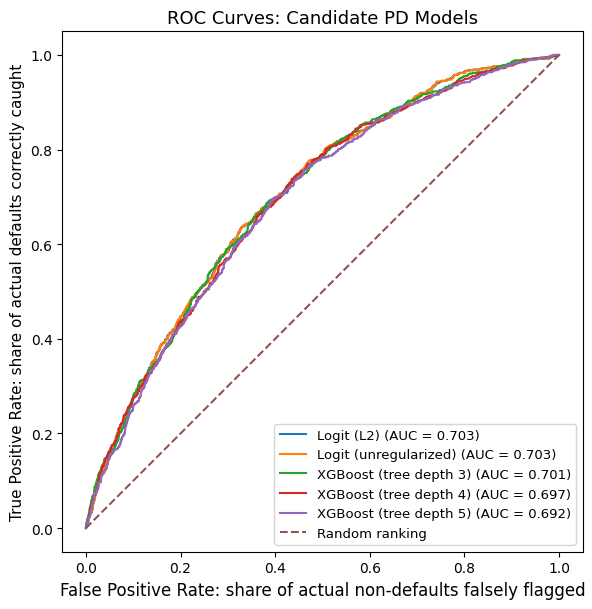

In [24]:
# Plot candidate ROC curves.

plt.figure(figsize=(8.0, 6.2))

for model_name in model_predictions.keys():
    plt.plot(
        roc_results[model_name]['fpr'],
        roc_results[model_name]['tpr'],
        label=f"{model_name} (AUC = {auc_results[model_name]:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random ranking'
)

plt.xlabel(
    'False Positive Rate: share of actual non-defaults falsely flagged',
    fontsize=12
)
plt.ylabel(
    'True Positive Rate: share of actual defaults correctly caught',
    fontsize=11
)
plt.title('ROC Curves: Candidate PD Models', fontsize=13)
plt.legend(fontsize=9.5, loc='lower right')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()


**Results:** The candidate models show broadly similar discriminatory power. Unregularized Logit reaches an AUC of `0.703`, L2 Logit `0.703`, and XGBoost depth 3 `0.701`; the deeper XGBoost specifications are somewhat weaker. The small differences at the top do not provide a strong basis for model selection on discrimination alone.


### Calibration

Loans are ranked by predicted PD and divided into ten similarly sized groups. Within each group, the average predicted PD is compared with the realized default rate.

Expected Calibration Error (ECE) summarizes the average absolute gap between predicted PD and realized default rate across these groups. The Brier score is the average squared difference between predicted PD and the realized 0/1 outcome. Lower values are better for both measures.


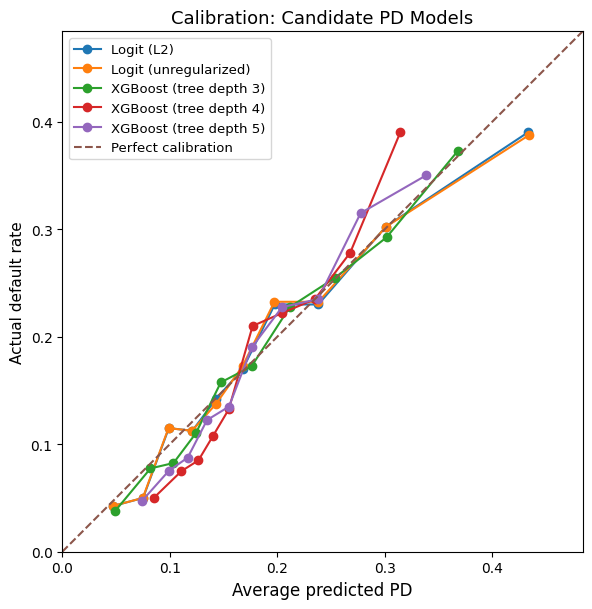

In [25]:
# Calibration curves based on ten quantile bins.

from sklearn.calibration import calibration_curve

calibration_results = {}

for model_name, prob_default in model_predictions.items():

    actual_default_rate, mean_predicted_PD = calibration_curve(

        y_test,

        prob_default,

        n_bins=10,

        strategy='quantile'

    )

    calibration_results[model_name] = {

        'actual_default_rate': actual_default_rate,

        'mean_predicted_PD': mean_predicted_PD

    }

plot_max = max(

    max(

        results['actual_default_rate'].max(),

        results['mean_predicted_PD'].max()

    )

    for results in calibration_results.values()

) + 0.05

plt.figure(figsize=(8.0, 6.2))

for model_name, results in calibration_results.items():
    plt.plot(
        results['mean_predicted_PD'],
        results['actual_default_rate'],
        marker='o',
        label=model_name
    )

plt.plot(
    [0, plot_max],
    [0, plot_max],
    linestyle='--',
    label='Perfect calibration'
)

plt.xlim(0, plot_max)
plt.ylim(0, plot_max)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('Average predicted PD', fontsize=12)
plt.ylabel('Actual default rate', fontsize=11)
plt.title('Calibration: Candidate PD Models', fontsize=13)
plt.legend(fontsize=9.5, loc='upper left')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


**Results:** XGBoost depth 3 remains comparatively close to the perfect-calibration line across the risk distribution. Depth 4 and 5 show more underestimation in higher-risk groups, while both Logit variants tend to overestimate risk somewhat at the upper end. The two Logit calibration curves are almost identical.


### Model comparison

Note that training-sample cross-validation slightly favors depth 4 in terms of AUC (CV AUC 0.688 vs. 0.687 for depth 3). On the common test sample, however, XGBoost with tree depth 3 records the lowest observed ECE and Brier score and is therefore carried forward for the business exercise. The performance differences between models have not been shown to be statistically significant, so the evidence for a superior model is suggestive rather than decisive. At the same time, both Logit specifications remain strong and more interpretable benchmarks.


In [26]:
# Summarize discrimination and probability accuracy with AUC, Brier score and ECE.

from sklearn.metrics import brier_score_loss

def expected_calibration_error(y_true, prob_default, n_bins=10):

    calibration_df = pd.DataFrame({

        'actual': np.asarray(y_true, dtype=float),

        'predicted_PD': prob_default

    })

    calibration_df['PD_bin'] = pd.qcut(

        calibration_df['predicted_PD'],

        q=n_bins,

        duplicates='drop'

    )

    calibration_groups = (

        calibration_df

        .groupby('PD_bin', observed=True)

        .agg(

            n=('actual', 'size'),

            actual_default_rate=('actual', 'mean'),

            mean_predicted_PD=('predicted_PD', 'mean')

        )

    )

    ece = np.average(

        abs(

            calibration_groups['actual_default_rate']

            - calibration_groups['mean_predicted_PD']

        ),

        weights=calibration_groups['n']

    )

    return ece

validation_results = []

for model_name, prob_default in model_predictions.items():

    validation_results.append({

        'Model': model_name,

        'AUC': roc_auc_score(

            y_test,

            prob_default

        ),

        'Brier score': brier_score_loss(

            np.asarray(y_test, dtype=int),

            prob_default

        ),

        'ECE (10 bins)': expected_calibration_error(

            y_test,

            prob_default,

            n_bins=10

        )

    })

validation_table = (

    pd.DataFrame(validation_results)

    .set_index('Model')

)

print(validation_table)


                             AUC  Brier score  ECE (10 bins)
Model                                                       
Logit (L2)              0.702805     0.135969       0.014185
Logit (unregularized)   0.703166     0.136007       0.015242
XGBoost (tree depth 3)  0.701089     0.135691       0.009567
XGBoost (tree depth 4)  0.696614     0.137255       0.030413
XGBoost (tree depth 5)  0.691534     0.137182       0.020106


## 4. From PDs to lending decisions

The XGBoost tree-depth-3 predictions are applied to the test sample in a hypothetical lending-policy exercise, illustrating two ways to define a lending policy.

- **PD-threshold strategy:** accept loans with predicted PD <= 20%. This implies an acceptance rate of 62.1% (2,485 loans).
- **Acceptance-rate strategy:** accept 85% of loans, selecting those with the lowest predicted PDs. This implies a PD cutoff of about 30.1% (3,400 loans).

The first strategy fixes the maximum accepted PD and lets business volume follow, while the second fixes the acceptance rate and therefore the required PD cutoff. Which approach is preferred ultimately depends on the lender's business priorities and risk preferences.


In [27]:
# Test-sample lending-policy exercise using XGBoost tree-depth-3 PDs.

business_df = pd.DataFrame({

    'prob_default': model_predictions['XGBoost (tree depth 3)'],

    'true_loan_status': np.asarray(y_test, dtype=int),

    'loan_amnt': X_test['loan_amnt'].to_numpy()

})


In [28]:
# Two illustrative lending policies: PD threshold of 20% and acceptance rate of 85%.

pd_threshold = 0.20

accepted_pd_threshold = (

    business_df['prob_default'] <= pd_threshold

)

pd_threshold_acceptance = accepted_pd_threshold.mean()

target_acceptance = 0.85

acceptance_rate_cutoff = np.quantile(

    business_df['prob_default'],

    target_acceptance

)

accepted_acceptance_rate = (

    business_df['prob_default'] <= acceptance_rate_cutoff

)

realized_acceptance_rate = accepted_acceptance_rate.mean()

strategy_table = pd.DataFrame({

    'Strategy': [

        'PD threshold: 20%',

        'Acceptance rate: 85%'

    ],

    'PD threshold': [

        pd_threshold,

        acceptance_rate_cutoff

    ],

    'Acceptance rate': [

        pd_threshold_acceptance,

        realized_acceptance_rate

    ],

    'Number accepted': [

        accepted_pd_threshold.sum(),

        accepted_acceptance_rate.sum()

    ]

})

print(strategy_table)


               Strategy  PD threshold  Acceptance rate  Number accepted
0     PD threshold: 20%      0.200000          0.62125             2485
1  Acceptance rate: 85%      0.301199          0.85000             3400


**Results:** A maximum accepted PD of 20% produces an acceptance rate of 62.1% (2,485 loans). Accepting the safest 85% instead implies a PD cutoff of about 30.1% (3,400 loans). Increasing business volume therefore requires accepting loans with higher predicted default risk.


## 5. Portfolio quality and expected loss

### Bad rate

$$
\text{Bad Rate}
=
\frac{\text{Accepted loans that later default}}
{\text{All accepted loans}}.
$$

The bad rate measures the share of accepted loans that later default.


In [29]:
# Ex-post bad rate among accepted loans, benchmarked against the full test sample.

bad_rate_pd_threshold = business_df.loc[

    accepted_pd_threshold,

    'true_loan_status'

].mean()

bad_rate_acceptance_rate = business_df.loc[

    accepted_acceptance_rate,

    'true_loan_status'

].mean()

overall_default_rate = business_df['true_loan_status'].mean()

bad_rate_table = pd.DataFrame({

    'Strategy': [

        'Full test sample',

        'PD threshold: 20%',

        'Acceptance rate: 85%'

    ],

    'Acceptance rate': [

        1.00,

        pd_threshold_acceptance,

        realized_acceptance_rate

    ],

    'Bad rate': [

        overall_default_rate,

        bad_rate_pd_threshold,

        bad_rate_acceptance_rate

    ]

})

print(bad_rate_table)


               Strategy  Acceptance rate  Bad rate
0      Full test sample          1.00000  0.178500
1     PD threshold: 20%          0.62125  0.111066
2  Acceptance rate: 85%          0.85000  0.144706


**Results:** While the full test sample has a default rate of 17.9%, both model-based strategies reduce this rate. The PD-threshold strategy produces the lower bad rate at 11.1%, while the acceptance-rate strategy raises lending volume but also the bad rate to 14.5%.


### Expected loss

Expected loss (EL) is calculated loan by loan as

$$
EL_i = PD_i \times LGD_i \times EAD_i,
$$

where loss given default (LGD) is the share of exposure lost if default occurs and exposure at default (EAD) is the amount exposed at the time of default. For this illustration, the original loan amount is used as a simplified EAD proxy and LGD is set to 100%. The EL rate is total expected loss relative to total EAD.


In [30]:
# Illustrative expected loss: EAD = original loan amount; LGD = 100%.

business_df['EAD'] = business_df['loan_amnt']

business_df['LGD'] = 1.0

business_df['expected_loss'] = (

    business_df['prob_default']

    * business_df['LGD']

    * business_df['EAD']

)


In [31]:
# Aggregate EAD, expected loss and EL rate for the two accepted portfolios.

def portfolio_EL_summary(accepted, strategy_name):

    portfolio = business_df.loc[accepted]

    total_EAD = portfolio['EAD'].sum()

    total_EL = portfolio['expected_loss'].sum()

    return {

        'Strategy': strategy_name,

        'Acceptance rate': accepted.mean(),

        'Number accepted': accepted.sum(),

        'Total EAD': total_EAD,

        'Total expected loss': total_EL,

        'Expected loss rate': total_EL / total_EAD

    }

expected_loss_table = pd.DataFrame([

    portfolio_EL_summary(

        accepted_pd_threshold,

        'PD threshold: 20%'

    ),

    portfolio_EL_summary(

        accepted_acceptance_rate,

        'Acceptance rate: 85%'

    )

])

print(expected_loss_table)


               Strategy  Acceptance rate  Number accepted   Total EAD  \
0     PD threshold: 20%          0.62125             2485  35397500.0   
1  Acceptance rate: 85%          0.85000             3400  49536950.0   

   Total expected loss  Expected loss rate  
0         4.091468e+06            0.115586  
1         7.615920e+06            0.153742  


**Results:** Moving from the PD-threshold strategy to the acceptance-rate strategy increases accepted exposure by about 40% (from 35.40m to 49.54m), while expected loss increases by about 86% (from 4.09m to 7.62m). The expected-loss rate rises from 11.6% to 15.4%. The higher acceptance rate therefore increases both lending volume and average credit risk.


## 6. Conclusion

The Logit and XGBoost models produce similar ranking performance in the test sample. XGBoost with tree depth 3 is carried forward because it records the lowest observed ECE and Brier score in the comparison, although the differences are small and not necessarily statistically significant. Both Logit models remain strong and more interpretable alternatives.

The lending exercise shows how different PD cutoffs affect the share of loans accepted, the bad rate and expected loss. Higher acceptance increases lending volume, but also brings higher average credit risk into the portfolio.

While the exercise remains simplified, it provides a compact application of PD estimation, validation and lending decisions.
